# [MATH2504 Programming of Simulation, Analysis, and Learning Systems at The University of Queensland](https://courses.smp.uq.edu.au/MATH2504/)

## Semester 2, 2026

# Practical E: Towards project B

Note that we use the [GitHub repo](https://github.com/MATH25042026/MATH2504_2026_ProjectB_template) for the base [project](https://dietmaroelz.github.io/ProgrammingCourse-with-Julia-SimulationAnalysisAndLearningSystems/quarto/Assessment/projectB.html).

In [2]:
using Pkg;
# To be able to run this, have the worksheet inside the project repository, it should not be part of your assignment submission. 
Pkg.activate(".");
# Pkg.instantiate(); #This should be uncommented when the project is first run
using PolynomialAlgebra

  Activating project at `~/github/MATH2504_2026_ProjectB`


# We'll create a rational function type which is a ratio of two polynomials.

$$
r(x) = \frac{p(x)}{q(x)}.
$$

Ideally such a function would allow a representation where any joint factors are cancelled out. However we won't get to this. 

The purpose of creating such a type is to get a feel for what it is like to create another type that uses the `Polynomial` type.

In [3]:
struct RationalFunction
    numerator::Polynomial
    denominator::Polynomial
end

To create `x` we specify the type `PolynomialDense`. To find where this type is defined press command/control+t, and type PolynomialDense. This can be done with any object defined in the project.

In [4]:
x = x_poly(PolynomialDense{Int})
r1 = RationalFunction(5x^2-3x+4, 6x^4-2x+5)
r2 = RationalFunction(-3x+4, 2x^2-2x+5)

@show r1
@show r2;

r1 = RationalFunction(5⋅x^2 + -3⋅x^1 + 4⋅x^0, 6⋅x^4 + -2⋅x^1 + 5⋅x^0)
r2 = RationalFunction(-3⋅x^1 + 4⋅x^0, 2⋅x^2 + -2⋅x^1 + 5⋅x^0)


# We can create a `show` method

In [7]:
import Base: show

The IO argument in `show` ensures that this function is called whenever a `RationalFunction` object is displayed.

In [8]:
PolynomialAlgebra.evaluate(3x, 3)
#methods(PolynomialAlgebra.evaluate)

9

In [9]:
function show(io::IO, r::RationalFunction) 
    println(io, r.numerator)
    num_chars = max(length(string(r.numerator)),length(string(r.denominator)))
    println(io,"-"^num_chars)
    println(io,r.denominator)
end

show (generic function with 403 methods)

In [10]:
r1

5⋅x^2 + -3⋅x^1 + 4⋅x^0
----------------------
6⋅x^4 + -2⋅x^1 + 5⋅x^0


In [11]:
r2

-3⋅x^1 + 4⋅x^0
----------------------
2⋅x^2 + -2⋅x^1 + 5⋅x^0


# We can allow multiplication

In [12]:
import Base: *

In [13]:
*(rf1::RationalFunction, rf2::RationalFunction) =
         RationalFunction(rf1.numerator * rf2.numerator, rf1.denominator * rf2.denominator)

* (generic function with 359 methods)

In [14]:
r1*r2

-15⋅x^3 + 29⋅x^2 + -24⋅x^1 + 16⋅x^0
--------------------------------------------------------------
12⋅x^6 + -12⋅x^5 + 30⋅x^4 + -4⋅x^3 + 14⋅x^2 + -20⋅x^1 + 25⋅x^0


# We can create a derivative function

In [15]:
# do not overload derivative here as this would put PolynomialAlgebra.derivative out of sight
function ratderivative(r::RationalFunction)
    n = r.numerator
    d = r.denominator
    
    #The quoutient rule for derivative
    RationalFunction(derivative(n)*d - n*derivative(d) , d^2)
end

ratderivative (generic function with 1 method)

In [16]:
ratderivative(r1)

-60⋅x^5 + 54⋅x^4 + -96⋅x^3 + -10⋅x^2 + 50⋅x^1 + -7⋅x^0
------------------------------------------------------
36⋅x^8 + -24⋅x^5 + 60⋅x^4 + 4⋅x^2 + -20⋅x^1 + 25⋅x^0


# Adding two rational types

In [17]:
import Base: +

In [18]:
function +(rf1::RationalFunction, rf2::RationalFunction)
    # a/b + c/d
    a, b = rf1.numerator, rf1.denominator
    c, d = rf2.numerator, rf2.denominator
    common = b*d
    return RationalFunction(a*d + c*b, common)
end

+ (generic function with 270 methods)

In [19]:
r1+r2

-18⋅x^5 + 34⋅x^4 + -16⋅x^3 + 45⋅x^2 + -46⋅x^1 + 40⋅x^0
--------------------------------------------------------------
12⋅x^6 + -12⋅x^5 + 30⋅x^4 + -4⋅x^3 + 14⋅x^2 + -20⋅x^1 + 25⋅x^0


In [20]:
RationalFunction(1+x,x^2) + RationalFunction(3*one(PolynomialDense{Int}),x)

4⋅x^2 + 1⋅x^1
-------------
1⋅x^3


# Some sanity check

In [21]:
prod_der_A = ratderivative(r1*r2)

540⋅x^8 + -1752⋅x^7 + 2934⋅x^6 + -4044⋅x^5 + 3026⋅x^4 + -1512⋅x^3 + -1177⋅x^2 + 1002⋅x^1 + -280⋅x^0
-----------------------------------------------------------------------------------------------------------------------------------------------
144⋅x^12 + -288⋅x^11 + 864⋅x^10 + -816⋅x^9 + 1332⋅x^8 + -1056⋅x^7 + 1936⋅x^6 + -1912⋅x^5 + 1856⋅x^4 + -760⋅x^3 + 1100⋅x^2 + -1000⋅x^1 + 625⋅x^0


In [22]:
prod_der_B = r1*ratderivative(r2) + ratderivative(r1)*r2

6480⋅x^14 + -27504⋅x^13 + 72432⋅x^12 + -138456⋅x^11 + 187428⋅x^10 + -222840⋅x^9 + 200592⋅x^8 + -190412⋅x^7 + 151948⋅x^6 + -144660⋅x^5 + 77004⋅x^4 + 888⋅x^3 + -53385⋅x^2 + 30650⋅x^1 + -7000⋅x^0
---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
1728⋅x^18 + -5184⋅x^17 + 18144⋅x^16 + -29376⋅x^15 + 54864⋅x^14 + -63504⋅x^13 + 100584⋅x^12 + -119088⋅x^11 + 164088⋅x^10 + -158320⋅x^9 + 167172⋅x^8 + -147312⋅x^7 + 168164⋅x^6 + -137460⋅x^5 + 99750⋅x^4 + -57500⋅x^3 + 56250⋅x^2 + -37500⋅x^1 + 15625⋅x^0


Why are these different?

In [25]:
function ratevaluate(r::RationalFunction, x::T) where T <: Number
    PolynomialAlgebra.evaluate(r.numerator,x) // PolynomialAlgebra.evaluate(r.denominator,x)
end

ratevaluate (generic function with 1 method)

As you can see... they aren't different:

In [27]:
ratevaluate(prod_der_A, 2), ratevaluate(prod_der_B, 2)

(632//84681, 632//84681)

# Some operations that modify the polynomials

Say we wanted (for some obscure reason) to only have the polynomials with even absolute coefficients. That is, whenever there is a coefficient of the form $n$ for $nx^k$ then we must transform $n$ to be `abs(2*(n ÷ 2))`.

In [28]:
clean(n::Int) = abs(2*(n÷2)) #\div + [TAB]

clean (generic function with 1 method)

In [29]:
[(n, clean(n)) for n=-5:5] |> println

[(-5, 4), (-4, 4), (-3, 2), (-2, 2), (-1, 0), (0, 0), (1, 0), (2, 2), (3, 2), (4, 4), (5, 4)]


In [30]:
clean(t::Term) = Term(clean(t.coeff),t.degree)

clean (generic function with 2 methods)

In [31]:
Term(1,3)

1⋅x^3

In [32]:
cleaned = clean(Term(1,3))

0⋅x^3

In [33]:
iszero(cleaned)

true

In [47]:
function clean(p::PolynomialDense{T}) where T
    p_out = PolynomialDense{T}()
    terms = deepcopy(p).terms
    for t in terms
        clean_t = clean(t)
        !iszero(clean_t) && push!(p_out,clean(t))
    end
    return p_out
end

clean (generic function with 5 methods)

In [48]:
PolynomialDense{Int}([Term(5,3),Term(2,2)])

5⋅x^3 + 2⋅x^2

In [49]:
clean(PolynomialDense{Int}([Term(5,3),Term(2,2)]))

4⋅x^3 + 2⋅x^2

In [51]:
using Random; Random.seed!(0)
p = rand(PolynomialDense{Int}) + 1x^50

1⋅x^50 + 77⋅x^10 + 52⋅x^9 + 87⋅x^8 + 63⋅x^7 + 45⋅x^6 + 58⋅x^4 + 43⋅x^3 + 9⋅x^2 + 64⋅x^0

In [52]:
clean(p)

76⋅x^10 + 52⋅x^9 + 86⋅x^8 + 62⋅x^7 + 44⋅x^6 + 58⋅x^4 + 42⋅x^3 + 8⋅x^2 + 64⋅x^0

Say now we wanted to do this to the `RationalFunction` type:

In [53]:
clean(r::RationalFunction) = RationalFunction(clean(r.numerator), clean(r.denominator))

clean (generic function with 6 methods)

In [54]:
r1

5⋅x^2 + -3⋅x^1 + 4⋅x^0
----------------------
6⋅x^4 + -2⋅x^1 + 5⋅x^0


In [55]:
clean(r1)

4⋅x^2 + 2⋅x^1 + 4⋅x^0
---------------------
6⋅x^4 + 2⋅x^1 + 4⋅x^0


## Abstract Types and Dispatch
Every object (number, variable, function, ...) in Julia has a concrete type, which can be found by querying `typeof`

In [56]:
@show typeof(1.0)
@show typeof(1)
@show typeof(1//1)

typeof(1.0) = Float64
typeof(1) = Int64
typeof(1 // 1) = Rational{Int64}


Rational{Int64}

These types are organised into collections known as Abstract types. We can recognise if a concrete type belongs to an Abstract type by using `<:` 

In [57]:
@show Float64 <: Number #Float64 is a subtype of Number
@show Int <: Integer <: Number #Int is a shorthand (alias) for Int64, Int64 is a subtype of Integer which is a subtype of Number
@show Float64 <: Integer #Float64 is not a subtype of Integer

Float64 <: Number = true
Int <: Integer <: Number = true
Float64 <: Integer = false


false

We can create our own concrete and abstract types. Consider a project involving points in 2D, we have two types of points, some are Integer valued, others are decimals. We can create two concrete types to store them. 

In [58]:
struct PointFloat_attempt1
    x::Float64
    y::Float64
end

struct PointInt_attempt1
    x::Int
    y::Int
end

FloatPoints = [PointFloat_attempt1(3rand(), 3rand()) for _ in 1:10] #10 random floating points in [0,3]×[0,3]
IntPoints = [PointInt_attempt1(i,j) for i in 1:3 for j in 1:3] #9 integer points at x=(1,2,3), y=(1,2,3)

9-element Vector{PointInt_attempt1}:
 PointInt_attempt1(1, 1)
 PointInt_attempt1(1, 2)
 PointInt_attempt1(1, 3)
 PointInt_attempt1(2, 1)
 PointInt_attempt1(2, 2)
 PointInt_attempt1(2, 3)
 PointInt_attempt1(3, 1)
 PointInt_attempt1(3, 2)
 PointInt_attempt1(3, 3)

We can then define methods that accept these new types as arguments.

In [59]:
function norm(point::PointFloat_attempt1)
    return sqrt(point.x^2 + point.y^2)
end

function norm(point::PointInt_attempt1)
    return sqrt(point.x^2 + point.y^2)
end

@show norm.(FloatPoints)
@show norm.(IntPoints)

norm.(FloatPoints) = [0.4795596430049197, 1.2033986430047587, 2.722018274317667, 2.472887972213921, 3.8478256620041265, 3.868927031059473, 1.2007569361038695, 1.90207295104667, 1.7767807957122475, 2.6152002182488103]
norm.(IntPoints) = [1.4142135623730951, 2.23606797749979, 3.1622776601683795, 2.23606797749979, 2.8284271247461903, 3.605551275463989, 3.1622776601683795, 3.605551275463989, 4.242640687119285]


9-element Vector{Float64}:
 1.4142135623730951
 2.23606797749979
 3.1622776601683795
 2.23606797749979
 2.8284271247461903
 3.605551275463989
 3.1622776601683795
 3.605551275463989
 4.242640687119285

Notice the actual code in the two methods is identical, we just needed to create two to handle both types. We could have instead used a shorthand to define both simultaneously. 

In [60]:
function norm2(point::T) where {T <: Union{PointFloat_attempt1, PointInt_attempt1}} #the type T can be either PointFloat_attempt1 or PointInt_attempt1
    return sqrt(point.x^2 + point.y^2)
end

@show norm2.(FloatPoints)
@show norm2.(IntPoints)

norm2.(FloatPoints) = [0.4795596430049197, 1.2033986430047587, 2.722018274317667, 2.472887972213921, 3.8478256620041265, 3.868927031059473, 1.2007569361038695, 1.90207295104667, 1.7767807957122475, 2.6152002182488103]
norm2.(IntPoints) = [1.4142135623730951, 2.23606797749979, 3.1622776601683795, 2.23606797749979, 2.8284271247461903, 3.605551275463989, 3.1622776601683795, 3.605551275463989, 4.242640687119285]


9-element Vector{Float64}:
 1.4142135623730951
 2.23606797749979
 3.1622776601683795
 2.23606797749979
 2.8284271247461903
 3.605551275463989
 3.1622776601683795
 3.605551275463989
 4.242640687119285

# Making out own abstract types
We can simplify this by introducing an abstract type  

In [61]:

abstract type Point2 end

Note we get an error if we try to redefine the existing types, either by declaring them as a subtype of trying to change the fields, which you can see by uncommenting the below. To make these changes we'd have to reboot the kernel before running the new definitions. We'll instead use a new name. 

In [62]:

# struct PointFloat_attempt1 <: Point2 #error because we're changing the type structure
#     x::Float64
#     y::Float64
# end

# struct PointFloat_attempt1  
#     x::Float64
#     y::Float64
#     z::Float64 #error because we're changing the fields
# end

In [63]:
struct PointFloat_attempt2 <: Point2 #the new concrete type PointFloat_attempt2 is declared as a subtype of the abstract type Point2
    x::Float64
    y::Float64
end

struct PointInt_attempt2 <: Point2
    x::Int
    y::Int
end

FloatPoints2 = [PointFloat_attempt2(3rand(), 3rand()) for _ in 1:10] #10 random floating points in [0,3]×[0,3]
IntPoints2 = [PointInt_attempt2(i,j) for i in 1:3 for j in 1:3] #9 integer points at x=(1,2,3), y=(1,2,3)

9-element Vector{PointInt_attempt2}:
 PointInt_attempt2(1, 1)
 PointInt_attempt2(1, 2)
 PointInt_attempt2(1, 3)
 PointInt_attempt2(2, 1)
 PointInt_attempt2(2, 2)
 PointInt_attempt2(2, 3)
 PointInt_attempt2(3, 1)
 PointInt_attempt2(3, 2)
 PointInt_attempt2(3, 3)

In [64]:
norm(point::Point2) = sqrt(point.x^2 + point.y^2)

@show norm.(FloatPoints2)
@show norm.(IntPoints2);

norm.(FloatPoints2) = [2.800964771015393, 1.4033553529552751, 3.3569202075045212, 2.2732682574273295, 1.8527696661419566, 2.4336266110554114, 2.8159498308210336, 2.2404940872023973, 2.6211634698159054, 1.8994433025754678]
norm.(IntPoints2) = [1.4142135623730951, 2.23606797749979, 3.1622776601683795, 2.23606797749979, 2.8284271247461903, 3.605551275463989, 3.1622776601683795, 3.605551275463989, 4.242640687119285]


If we want we can create a function specifically for a concrete type. This will be important in the project because `PolynomialDense` and `PolynomialSparse` will have different structures, and many functions will need to be specific to type. 

In [65]:
function norm(point::PointInt_attempt2)
    println("Finding norm of an integer point")
    return sqrt(point.x^2 + point.y^2)
end

norm(IntPoints2[1])


Finding norm of an integer point


1.4142135623730951

When a function is called, it will dispatch to the most specific type it can find. Right now, `PointInt_attempt2` has 2 methods defined - one on its concrete type, and another on the abstract type `Point2` - the one on the concrete type is more specific (`PointInt_attempt2 <: Point2`), so will be used. The other concrete type `PointFloat_attempt2` still uses the norm defined on the abstract type, and therefore doesn't print any text. 

In [66]:
norm(FloatPoints2[1])

2.800964771015393

We can see all the methods associated with a function name by using the `methods` function below, for any function that comes with Julia (+,-,*,...) or any packages being used you can expect very many methods

In [67]:
methods(norm)

# 4 methods for generic function "norm" from Main:
 [1] norm(point::PointInt_attempt2)
     @ In[65]:1
 [2] norm(point::PointInt_attempt1)
     @ In[59]:5
 [3] norm(point::PointFloat_attempt1)
     @ In[59]:1
 [4] norm(point::Point2)
     @ In[64]:1

We can even reference the type of our arguments in the body of the function - here we use it to determine the colour when plotting the points. 

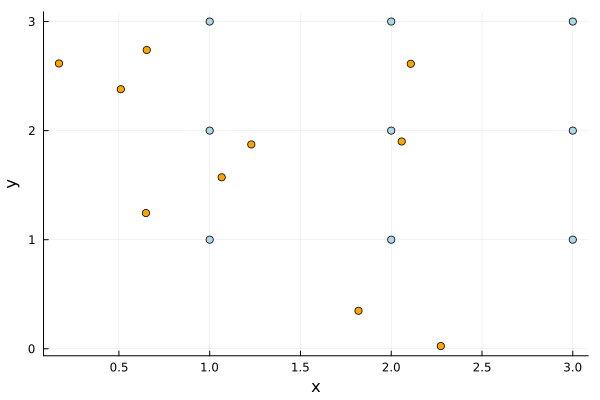

In [68]:
using Plots
## This function inputs a vector containing elements of type T, where T is a subtype of Point2. This means T will be either PointInt_attempt2 or PointFloat_attempt2. If they are integer points they're plotted in blue, otherwise they are plotted in orange. 
function plotpoints(points::Vector{T}; plt=plot()) where {T <: Point2}
    plot!(plt, xlabel="x", ylabel="y", legend=:none)
    scatter!(
        [p.x for p in points], #unpack all x values from points
        [p.y for p in points], #unpack all y values from points
        color = (T==PointInt_attempt2) ? :lightblue : :orange  #check the type T, which is used to determine the colour
    )
end
plt = plotpoints(FloatPoints2)
plt = plotpoints(IntPoints2; plt=plt)

This feature is used in the project - for example consider this function from `src/polynomial_definitions/polynomial.jl` - it accepts an argument of type `P`, which must be a subtype of `Polynomial`. The first line of the function then creates an empty polynomial of type `P`. Currently the only subtype of `Polynomial` is `PolynomialDense`, but you'll create another in Task 3. 

In [69]:
"""
Create a new polynomial which is the derivative of the polynomial.
"""
function derivative(p::P)::P where {P <: Polynomial} 
    der_p = P()
    for term in p
        der_term = derivative(term)
        !iszero(der_term) && push!(der_p, der_term)
    end
    return trim!(der_p)
end

derivative

We can combine these syntaxes to quickly generate many concrete types simultaneously, these are named [parametric types](https://docs.julialang.org/en/v1/manual/types/#Parametric-Types).

In [70]:
struct Point_attempt3{T <: Real} <: Point2 #With this signature we're creating a new concrete type Point_attempt3{T} for every subtype of Real. All the new concrete types will be subtypes of Point2
    x::T
    y::T
end



FloatPoints3 = [Point_attempt3{Float64}(3rand(), 3rand()) for _ in 1:10] #10 random floating points in [0,3]×[0,3]
IntPoints3 = [Point_attempt3{Int}(i,j) for i in 1:3 for j in 1:3] #9 integer points at x=(1,2,3), y=(1,2,3)

9-element Vector{Point_attempt3{Int64}}:
 Point_attempt3{Int64}(1, 1)
 Point_attempt3{Int64}(1, 2)
 Point_attempt3{Int64}(1, 3)
 Point_attempt3{Int64}(2, 1)
 Point_attempt3{Int64}(2, 2)
 Point_attempt3{Int64}(2, 3)
 Point_attempt3{Int64}(3, 1)
 Point_attempt3{Int64}(3, 2)
 Point_attempt3{Int64}(3, 3)

In [71]:
Point_attempt3{Int} <: Point_attempt3

true

These are declared as subtypes of the abstract type `Point2`, so any method defined on `Point2` will already work. 

norm.(FloatPoints3) = [1.0593818089674165, 2.0724120384579146, 2.8034070571529934, 0.9883259837551682, 1.9450746004372195, 1.6668872586285155, 1.949057683448323, 2.0059920356715164, 2.5043591789908692, 2.673973980201795]
norm.(IntPoints3) = [1.4142135623730951, 2.23606797749979, 3.1622776601683795, 2.23606797749979, 2.8284271247461903, 3.605551275463989, 3.1622776601683795, 3.605551275463989, 4.242640687119285]


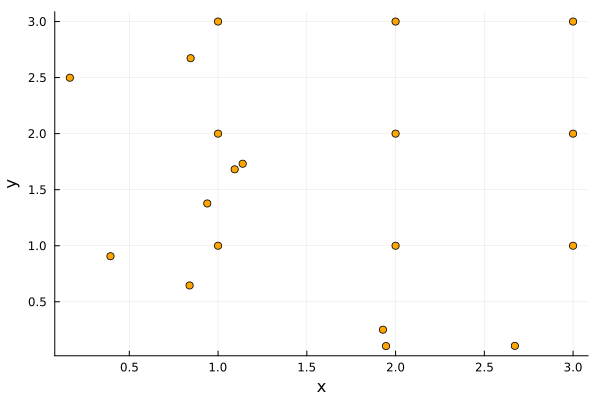

In [72]:
@show norm.(FloatPoints3)
@show norm.(IntPoints3)

plt = plotpoints(FloatPoints3)
plotpoints(IntPoints3; plt=plt)

Now our integers are orange rather than blue (why?), we can fix this by defining a new method on `Point_attempt3{Int}` alone.

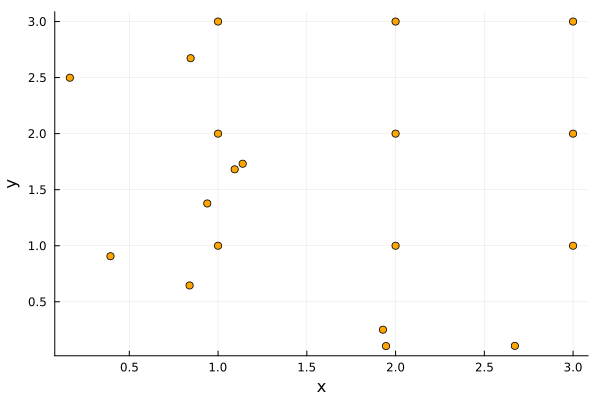

In [73]:
function plotpoints(points::Point_attempt3{Int}; plt=plot())
    plot!(plt, xlabel="x", ylabel="y", legend=:none)
    scatter!(
        [p.x for p in points], #unpack all x values from points
        [p.y for p in points], #unpack all y values from points
        color = :lightblue 
    )
end

plt = plotpoints(FloatPoints3)
plotpoints(IntPoints3; plt=plt) 

This still hasn't worked, where's the bug in the code cell above?

In [74]:
methods(plotpoints)

# 2 methods for generic function "plotpoints" from Main:
 [1] plotpoints(points::Point_attempt3{Int64}; plt)
     @ In[73]:1
 [2] plotpoints(points::Vector{T}; plt) where T<:Point2
     @ In[68]:3

There are now two (or more, depending on your changes) methods named `plotpoints`, which one is used when we call `plotpoints(FloatPoints3)`? How about when we call `plotpoints(IntPoints3; plt=plt)`?

Parametric typing like this is used extensively in `src\term.jl`, and you're asked to implement it yourself in task 2. 

## The Max Heap
The project includes a Max heap in `src/utils/heap.jl`, which you asked to use when implementing `PolynomialSparse` in Task 3. In the rest of this document we'll summarise how to generate and query these heaps. There are more details in the documentation written withen `heap.jl`. 

In [75]:
methods(Heap)

# 2 methods for type constructor:
 [1] Heap(::Type{T}) where T
     @ ~/github/MATH2504_2026_ProjectB/src/utils/heap.jl:52
 [2] Heap(v::Vector{T}) where T
     @ ~/github/MATH2504_2026_ProjectB/src/utils/heap.jl:60

We have two ways to generate a heap, the first inputs a type and generates an empty heap of that type, the second generates a heap based on an inputted vector. 

In [76]:
@show Heap(Float64) #empty heap with Floats
@show Heap([5,19,21,1,7]) #heap with integers

Heap(Float64) = Heap(Float64[])
Heap([5, 19, 21, 1, 7]) = Heap([21, 19, 5, 1, 7])


Heap([21, 19, 5, 1, 7])

The function `pop!` removes the largest element from the heap and returns it. Note that when displayed the heap may look unsorted, but `pop!` finds the largest value. 

In [77]:
@show h1 = Heap([1,5,3,7,2])
@show pop!(h1)
@show h1 
@show pop!(h1)
@show h1

h1 = Heap([1, 5, 3, 7, 2]) = Heap([7, 5, 3, 1, 2])
pop!(h1) = 7
h1 = Heap([5, 2, 3, 1])
pop!(h1) = 5
h1 = Heap([3, 2, 1])


Heap([3, 2, 1])

We can also add new elements to the heap using `push!`.

In [78]:
h2 = Heap([11,2,31,9])
push!(h2, 31)
@show h2

h2 = Heap([31, 31, 11, 2, 9])


Heap([31, 31, 11, 2, 9])

In [79]:
@show pop!(h2)
@show pop!(h2)
h2

pop!(h2) = 31
pop!(h2) = 31


Heap([11, 9, 2])

We may also use `peek` to return the largest value without modifying the heap.  

In [80]:
@show h2
@show peek(h2)
@show h2

h2 = Heap([11, 9, 2])
peek(h2) = 11
h2 = Heap([11, 9, 2])


Heap([11, 9, 2])

We may also apply an operation to an entire heap using `map_heap` (or `map_heap!` to do so in-place), this may be useful when multiplying a sparse polynomial.

In [92]:
h1 = Heap([1,5,3,7,2])
h2 = map(x->x^2, h1) #square all elements in h1

Heap([49, 25, 9, 1, 4])

In [93]:
peek(h2)

49

This assumes that the function $f$ being mapped is order-preserving, meaning that $x>y$ implies $f(x)>f(y)$. Let's see what happens when our function isn't order-preserving. 

In [95]:
f(x) = -x
h1 = Heap([1,5,3,7,2])
h2 = map(f, h1) #negate all elements in h1

Heap([-7, -5, -3, -1, -2])

In [97]:
@show peek(h2)
@show pop!(h2)

peek(h2) = -7
pop!(h2) = -7


-7

The order has now been broken, so now `pop!` and `peek` behave unpredictably, returning the smallest value, rather than the largest. 

We may also use `popall` to find the entire (sorted) vector associated with the heap (`popall!` to do so destructively)

In [99]:
h1 = Heap([1,5,3,7,2])
h2 = map(x->x^2, h1) #square all elements in h1
@show popall(h2)
@show isempty(h2)
@show h2
println() #print an empty line

h3 = Heap([1,5,3,7,2])
h4 = map(f, h3) 
@show popall(h4)
@show isempty(h4)
@show h4;

popall(h2) = [49, 25, 9, 4, 1]
isempty(h2) = false
h2 = Heap([49, 25, 9, 1, 4])

popall(h4) = [-1, -2, -3, -5, -7]
isempty(h4) = false
h4 = Heap([-7, -5, -3, -1, -2])


Note the `isempty` function used above which, predictably, queries whether the heap is empty. Looking into `heap.jl` we can see that this uses our last convenience function, `length`, which measures the number of elements stored in a heap. 

In [100]:
h1 = Heap(rand(10))
@show length(h1)
pop!(h1)
@show length(h1);

length(h1) = 10
length(h1) = 9
